[*********************100%***********************]  5 of 5 completed


MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'AMZN'),
            ( 'Close',  'DIS'),
            ( 'Close', 'NFLX'),
            ( 'Close',  'WBD'),
            (  'High', 'AAPL'),
            (  'High', 'AMZN'),
            (  'High',  'DIS'),
            (  'High', 'NFLX'),
            (  'High',  'WBD'),
            (   'Low', 'AAPL'),
            (   'Low', 'AMZN'),
            (   'Low',  'DIS'),
            (   'Low', 'NFLX'),
            (   'Low',  'WBD'),
            (  'Open', 'AAPL'),
            (  'Open', 'AMZN'),
            (  'Open',  'DIS'),
            (  'Open', 'NFLX'),
            (  'Open',  'WBD'),
            ('Volume', 'AAPL'),
            ('Volume', 'AMZN'),
            ('Volume',  'DIS'),
            ('Volume', 'NFLX'),
            ('Volume',  'WBD')],
           names=['Price', 'Ticker'])
DatetimeIndex(['2019-11-01', '2019-11-04', '2019-11-05', '2019-11-06',
               '2019-11-07', '2019-11-08', '2019-11-11', '2019-11-12',
               '201

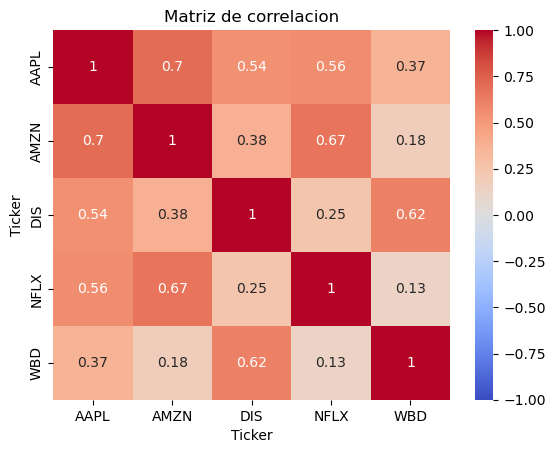

[0.2 0.2 0.2 0.2 0.2]
[0.2 0.2 0.2 0.2 0.2]
Ticker      AAPL      AMZN       DIS      NFLX       WBD
Ticker                                                  
AAPL    0.000793  0.000460  0.000444  0.000445  0.000329
AMZN    0.000460  0.000552  0.000259  0.000446  0.000134
DIS     0.000444  0.000259  0.000840  0.000203  0.000572
NFLX    0.000445  0.000446  0.000203  0.000801  0.000115
WBD     0.000329  0.000134  0.000572  0.000115  0.001023
La volatilidad diaria es:
0.020807339625785348
La volatilidad anual es:
0.3303062765681268


In [15]:
import pandas as pd
import numpy as np
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt

datos=yf.download(["NFLX","WBD","AMZN","DIS","AAPL"], start="2019-11-01", end="2020-12-01")


precio_cierre=datos['Close']
#precio de cierre: es el valor monetario de una acción al final del cierre de mercado (de la bolsa) de un día concreto

print(datos.columns)
#nos da las etiquetas de las columnas de la tabla

print(datos.index)
#nos da las etiquetas de las filas de la tabla

rentabilidad_diaria = precio_cierre.pct_change().dropna()

#DataFrame.pct_change(periods=1, fill_method=None, freq=None, **kwargs)
#periods - indica con cuántas filas atrás comparar
#fill_method=none - no rellenes nada automáticamente
#freq - se usa cuando el índice son fechas - comparas usando una frecuencia temporal concreta ("D" días, "M" meses, "Y" años)


#DataFrame.dropna(*, axis=0, how=<no_default>, thresh=<no_default>, subset=None, inplace=False, ignore_index=False)
#how="any" - borra si hay al menos un NAN
#how="all" - solo borra si todo es NAN
#dropna() = dropna(axis=0, how="any") borra filas completas que tengan al menos un NAN

matriz_correlacion=rentabilidad_diaria.corr()
print(matriz_correlacion)
#pintamos la matriz de correlación - la tabla

sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

#annot (muestra los nº dentro de las celdas)  - True (muestra valores) - False (no muestra valores)
#cmap - es el tipo de colores ('coolwarm', 'viridis', 'magma')
#vmin-vmax -- valor min-max del color

plt.title('Matriz de correlacion')
plt.show()

#conclusiones del análisis:
#los datos estudiados son justo las del primer año de covid-19 como vemos al estar la gente en casa, las plataformas de video aumentaron sus supcripciones
#por eso, todas las correlaciones son positivas, todas subieron a la vez...

w=np.array([0.20,0.20,0.20,0.20,0.20]) #diversificación del riesgo
print (w)
wt=np.transpose(w)
print(wt)

#"w" vector que indica que porcentaje del dinero meto en cada empresa

matriz_covarianza=rentabilidad_diaria.cov()
print(matriz_covarianza)

varianza_cartera=wt@matriz_covarianza@w
volatilidad_diaria=np.sqrt(varianza_cartera)

print('La volatilidad diaria es:')
print(volatilidad_diaria)

#En finanzas gracias a Harry Markowitz, el riesgo total de un sistema de acciones (cartera) no es la simple media de los riesgos individuales, depende de tres cosas:
#1.volatilidad de la empresa (cuanto fluctua por si sola)
#2.Peso (w) (que porcentaje de tu dinero metes a cada empresa)
#3.Covarianza (como interactuan entre ellas)

volatilidad_anual=np.sqrt(252)*volatilidad_diaria
print('La volatilidad anual es:')
print(volatilidad_anual)

